In [13]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [27]:
ruta_carpeta = Path(
    "../Resultados/02_Tabla_de_metricas_por_mes"
)

ruta_salida = Path(
    "../Resultados/03_Graficos_por_mes"
)
ruta_salida.mkdir(parents=True, exist_ok=True)

Acá abajo seleccionar la métrica que se quiere graficar

In [34]:
# Métrica a evaluar
# puede ser: NS,Pbias,CV,Pearson,CRPSSad,Brier_Q10,Brier_Q10_Q25,Brier_Q25_Q75,Brier_Q75_Q90,Brier_Q90
metrica_evaluar = "CRPSSad"

Seleccione los leadtimes que querés evaluar:

In [35]:
lead_times_evaluar = [2]

In [36]:
df_evaluacion = []

for ruta_csv in ruta_carpeta.glob("*.csv"):
    df = pd.read_csv(ruta_csv)
    cuenca = ruta_csv.stem

    if metrica_evaluar not in df.columns:
        raise ValueError(f"{metrica_evaluar} no está en {ruta_csv.name}")

    # seleccionar leads times deseados
    df_lead_selec = df[df["lead"].isin(lead_times_evaluar)]
    #print(df_lead_selec)
    
    # promedio sobre leads para cada mes
    df_mes = (
        df_lead_selec
        .groupby("mes")[metrica_evaluar]
        .mean()
        .reset_index()
    )
    #print (df_mes)
    
    df_mes["cuenca"] = cuenca
    df_evaluacion.append(df_mes)

#print (df_evaluacion)

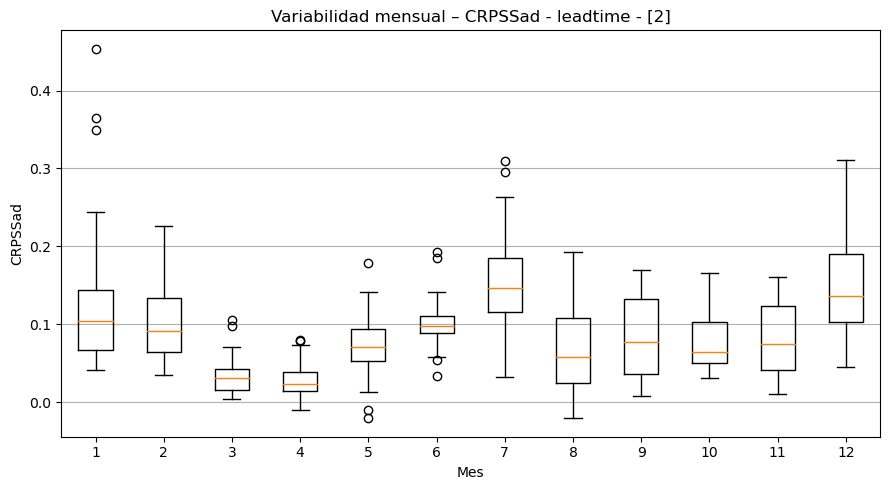

In [37]:
# DataFrame final y graficar

df_evaluacion = pd.concat(df_evaluacion, ignore_index=True)

meses = range(1, 13)

box_data = [
    df_evaluacion.loc[df_evaluacion["mes"] == m, metrica_evaluar].dropna()
    for m in meses
]

plt.figure(figsize=(9, 5))
plt.boxplot(box_data, labels=meses, showfliers=True)
plt.xlabel("Mes")
plt.ylabel(metrica_evaluar)
plt.title(f"Variabilidad mensual – {metrica_evaluar} - leadtime - {lead_times_evaluar}")
plt.grid(axis="y")
plt.tight_layout()

plt.savefig(ruta_salida / f"boxplot_mensual_{metrica_evaluar}_lead_{lead_times_evaluar}.png", dpi=300)
plt.show()